In [1]:
from ema_workbench import (
    Model, Policy, ema_logging,
    MultiprocessingEvaluator, save_results, load_results, Scenario
)
from ema_workbench.analysis import prim, cart, parcoords
from sklearn.preprocessing import minmax_scale
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from problem_formulation import get_model_for_problem_formulation
from dike_model_function import DikeNetwork
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import pdist, squareform
from concurrent.futures import ProcessPoolExecutor
import os
import itertools
import functools
import random
from assignment_10_scenario_selection import find_maxdiverse_scenarios
from ema_workbench.analysis import dimensional_stacking

In [3]:
# Enable logging
ema_logging.log_to_stderr(ema_logging.INFO)

# Load model formulation
dike_model, planning_steps = get_model_for_problem_formulation(3)

# Create a "do nothing" policy (no investment in any lever)
do_nothing = Policy("do nothing", **{lev.name: 0 for lev in dike_model.levers})

# Choose number of scenarios
n_scenarios = 10000  # Literature suggests 1000–10,000, this is a balanced choice

# Run model for scenarios with 1 policy
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(scenarios=n_scenarios, policies=[do_nothing])
    save_results(results, "scenario_selection.tar.gz")

[MainProcess/INFO] pool started with 12 workers
[MainProcess/INFO] performing 10000 scenarios * 1 policies * 1 model(s) = 10000 experiments
100%|████████████████████████████████████| 10000/10000 [12:57<00:00, 12.86it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] results saved successfully to C:\Users\milan\PycharmProjects\EMAworkbench\final assignment\scenario_selection.tar.gz
[MainProcess/INFO] terminating pool


In [2]:
# Load experiments and outcomes from saved file
experiments, outcomes = load_results('scenario_selection.tar.gz')

In [3]:
# Define outcomes and preferences
outcome_names = [
    'RfR Total Costs',
    'Expected Evacuation Costs',
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths'
]

preferences = {name: +1 for name in outcome_names}  # All to be minimized

# Compute mask for policy-relevant scenarios (where outcomes are worse than median)
medians = {o: np.median(outcomes[o]) for o in outcome_names}
y = np.ones(len(experiments), dtype=bool)
for o in outcome_names:
    if preferences[o] == +1:
        y &= outcomes[o] >= medians[o]
    else:
        y &= outcomes[o] <= medians[o]

experiments_of_interest = experiments.loc[y]
outcomes_df = pd.DataFrame({k: v[y] for k, v in outcomes.items() if k in outcome_names})

In [4]:
USE_DIVERSITY = False  # Set to False for best/worst-case selection and true for max diversity based

In [5]:
if USE_DIVERSITY:
    # --- DIVERSITY-BASED SELECTION ---
    scaler = MinMaxScaler()
    normalized_outcomes = pd.DataFrame(
        scaler.fit_transform(outcomes_df),
        columns=outcomes_df.columns,
        index=outcomes_df.index
    )

    distances = squareform(pdist(normalized_outcomes.values))
    sampled_combinations = [random.sample(range(len(normalized_outcomes)), 2) for _ in range(100000)]

    partial_function = functools.partial(find_maxdiverse_scenarios, distances)
    with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
        worker_data = np.array_split(sampled_combinations, os.cpu_count())
        results = list(itertools.chain.from_iterable(executor.map(partial_function, worker_data)))

    results.sort(key=lambda entry: entry[0], reverse=True)
    diversity_score, best_indices = results[0]

    print(f"\nMost diverse scenario indices: {best_indices}")

else:
    # --- BEST/WORST-CASE AGGREGATED SELECTION ---
    scaler = MinMaxScaler()
    normalized_outcomes = pd.DataFrame(
        scaler.fit_transform(outcomes_df),
        columns=outcomes_df.columns,
        index=outcomes_df.index
    )

    best_index = normalized_outcomes.sum(axis=1).idxmin()
    worst_index = normalized_outcomes.sum(axis=1).idxmax()
    best_indices = [normalized_outcomes.index.get_loc(best_index), normalized_outcomes.index.get_loc(worst_index)]

    print(f"\nBest/Worst scenario indices: {[best_index, worst_index]}")

# Common for both:
true_indices = outcomes_df.iloc[list(best_indices)].index
selected_experiments = experiments.loc[true_indices]
selected_outcomes = pd.DataFrame({k: outcomes[k][true_indices] for k in outcome_names})


Best/Worst scenario indices: [0, 6712]


In [6]:
selected_outcomes

,RfR Total Costs,Expected Evacuation Costs,A.5 Total Costs,A.5_Expected Number of Deaths
0,0.0,0.0,0.000000e+00,0.000000
1,0.0,0.0,1.490471e+09,1.115437


In [7]:
selected_experiments

,A.0_ID flood wave shape,A.1_Bmax,A.1_Brate,A.1_pfail,A.2_Bmax,A.2_Brate,A.2_pfail,A.3_Bmax,A.3_Brate,A.3_pfail,...,A.3_DikeIncrease 2,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,scenario,policy,model
0,24,32.292112,1.5,0.176063,310.257746,1.5,0.420761,159.622109,10.0,0.002416,...,0,0,0,0,0,0,0,0,do nothing,dikesnet
6712,23,232.160437,1.0,0.610874,292.021927,1.0,0.447854,304.023152,1.0,0.454530,...,0,0,0,0,0,0,0,6712,do nothing,dikesnet


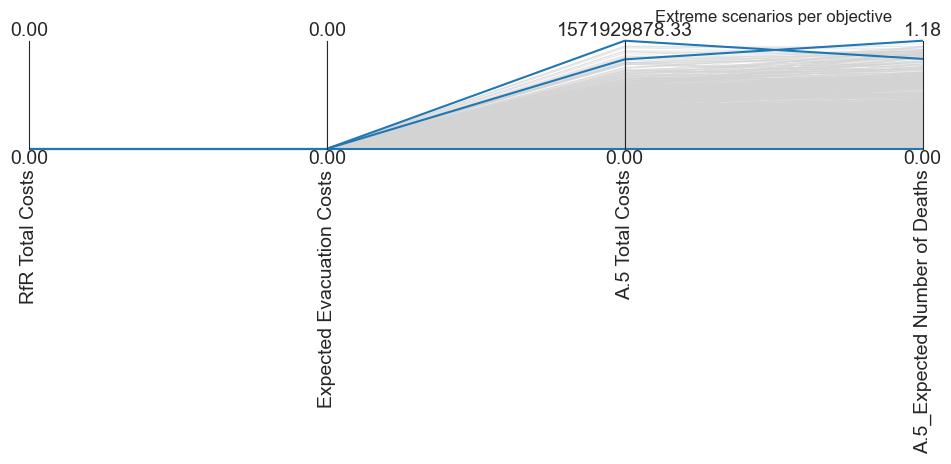

In [8]:
# STEP 4: Parallel coordinates plot with extremes
all_data = pd.DataFrame({k: outcomes[k] for k in outcome_names})
extreme_indices = pd.concat([all_data.idxmin(), all_data.idxmax()]).unique()
limits = parcoords.get_limits(all_data)
axes = parcoords.ParallelAxes(limits)
axes.plot(all_data, color='lightgrey', lw=0.5, alpha=0.5)
axes.plot(all_data.loc[extreme_indices], color=sns.color_palette()[0], lw=1.5)
fig = plt.gcf()
fig.set_size_inches((10, 4))
plt.title("Extreme scenarios per objective")
plt.show()


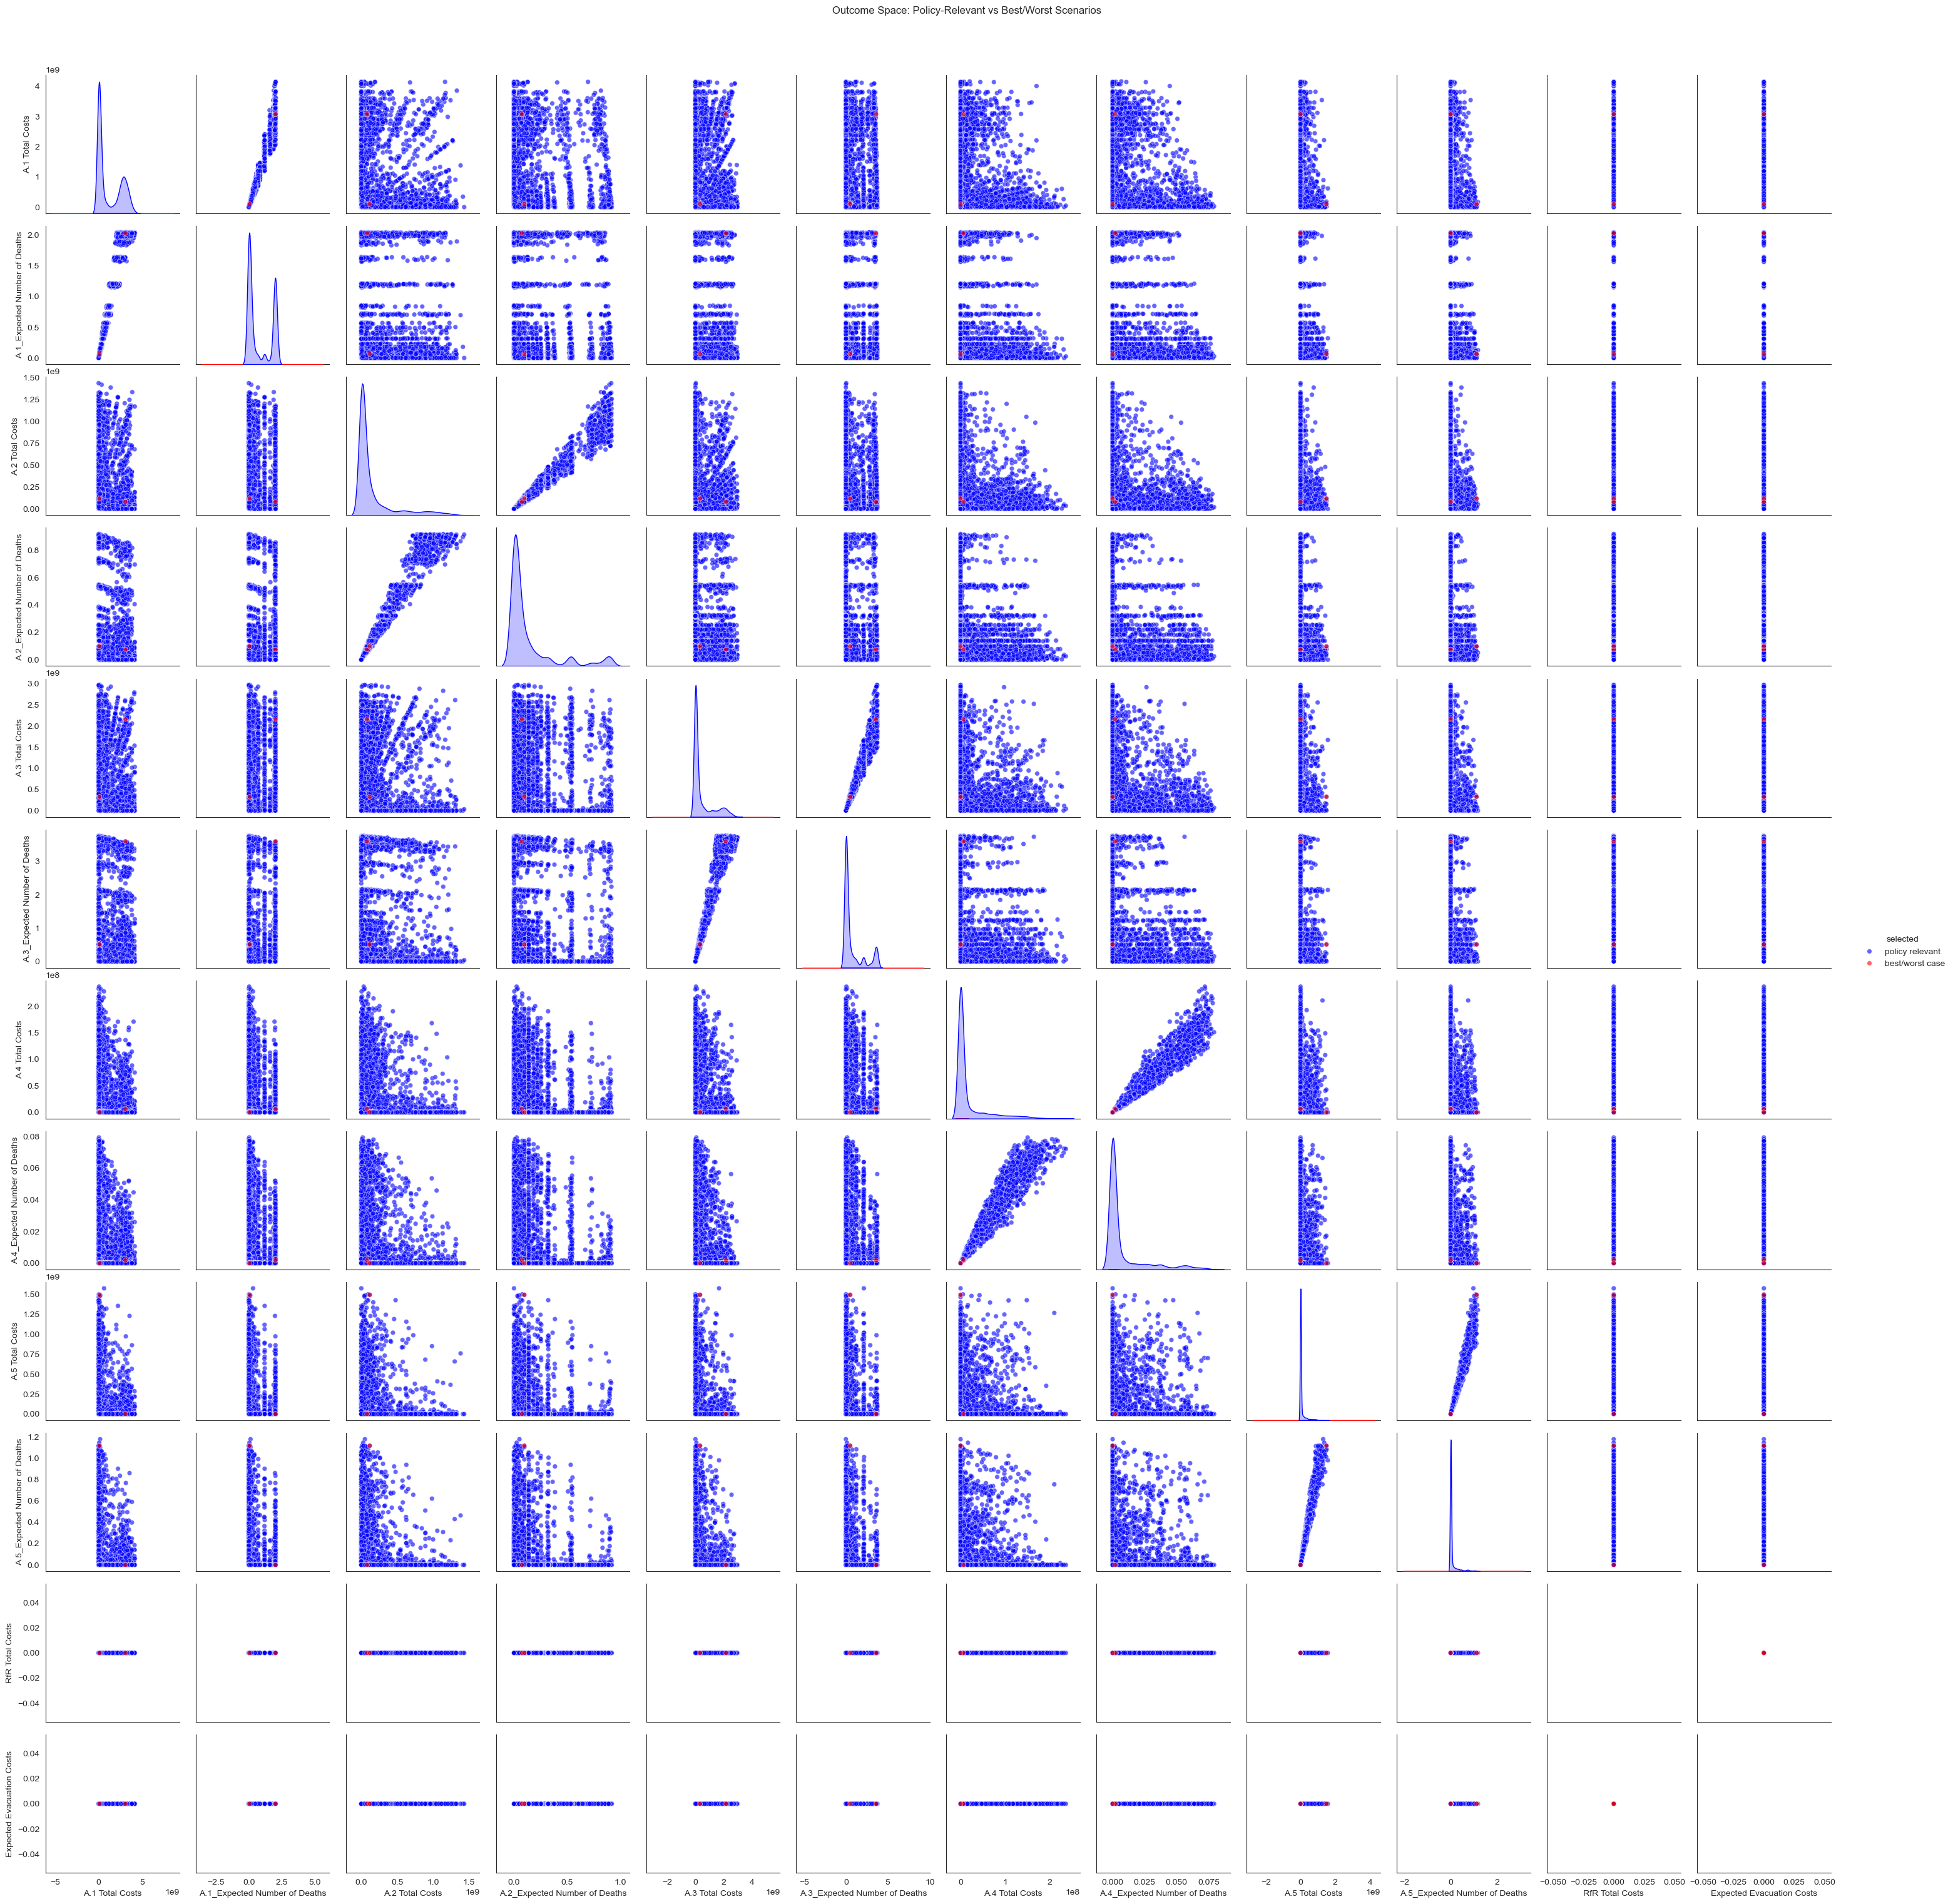

In [9]:
# STEP 5: Full outcome space pairplot (all outcomes)
full_outcomes_df = pd.DataFrame({k: v[y] for k, v in outcomes.items()})
full_outcomes_df = full_outcomes_df.copy()
full_outcomes_df['selected'] = 'policy relevant'
selected_labeled = full_outcomes_df.loc[true_indices].copy()
selected_labeled['selected'] = 'best/worst case'
combined_outcomes = pd.concat([full_outcomes_df, selected_labeled])

sns.pairplot(
    combined_outcomes,
    vars=full_outcomes_df.columns.drop('selected'),
    hue='selected',
    palette={'policy relevant': 'blue', 'best/worst case': 'red'},
    plot_kws={'alpha': 0.6, 's': 30}
)
plt.suptitle('Outcome Space: Policy-Relevant vs Best/Worst Scenarios', y=1.02)
plt.show()


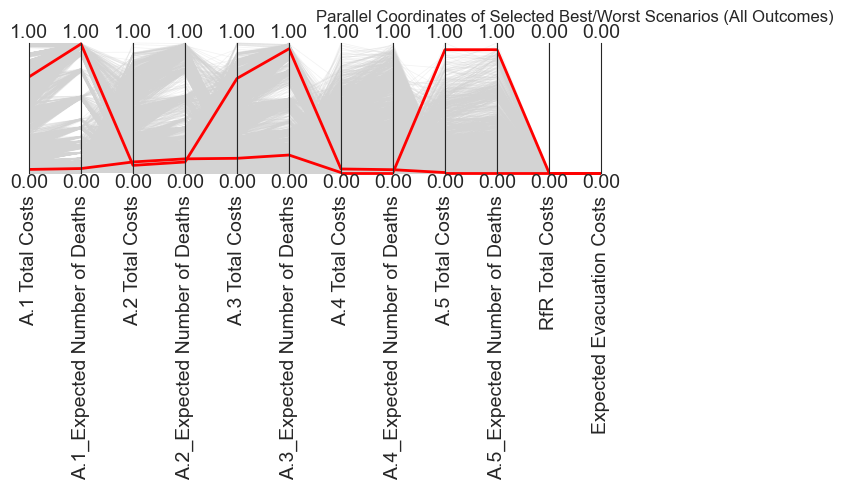

In [10]:
from sklearn.preprocessing import minmax_scale
from ema_workbench.analysis import parcoords

# Use all outcomes (not just selected ones)
full_combined_data = pd.DataFrame({k: v[y] for k, v in outcomes.items()})  # only policy-relevant
normalized_all = full_combined_data.copy()
normalized_all[full_combined_data.columns] = minmax_scale(full_combined_data)

# Selected 2 (best and worst case) from earlier
selected_out = normalized_all.loc[true_indices]

# Plot full space and highlight best/worst
limits = parcoords.get_limits(normalized_all)
ax = parcoords.ParallelAxes(limits)
ax.plot(normalized_all, color='lightgrey', lw=0.5, alpha=0.3)
ax.plot(selected_out, color='red', lw=2)
plt.title('Parallel Coordinates of Selected Best/Worst Scenarios (All Outcomes)')
plt.show()

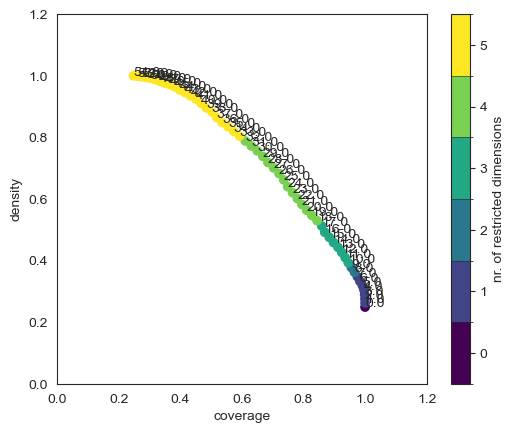

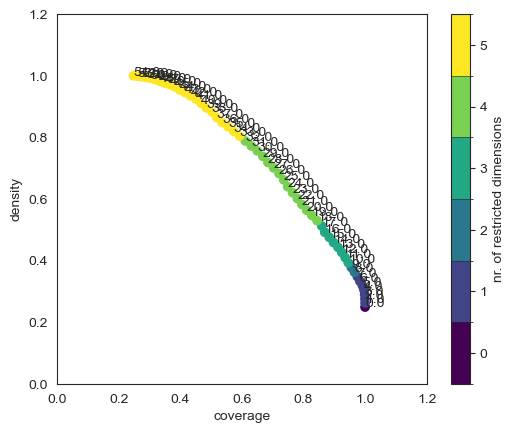

In [11]:
from ema_workbench.analysis import prim

# Binary classification mask for PRIM
y_prim = outcomes_df['A.5_Expected Number of Deaths'] > 0.001

# Use experiments_of_interest (same length as y_prim)

prim_alg = prim.Prim(experiments_of_interest, y_prim, threshold=0.8)
box = prim_alg.find_box()
box.show_tradeoff(annotated=True)

In [12]:
#Hier evt nog wat toevoegen om een aparte box te inspecteren

In [13]:
point = 27
box.inspect(point)

coverage       0.703094
density        0.700841
id            27.000000
k           1750.000000
mass           0.249700
mean           0.700841
n           2497.000000
res_dim        4.000000
Name: 27, dtype: float64

             box 27                                 
                min       max      qp value qp value
A.5_pfail  0.000021  0.357675           NaN      0.0
A.3_pfail  0.183651  0.999963  1.548951e-20      NaN
A.2_pfail  0.095697  0.999943  2.768080e-07      NaN
A.4_pfail  0.048904  0.999907  6.537682e-03      NaN



[None]

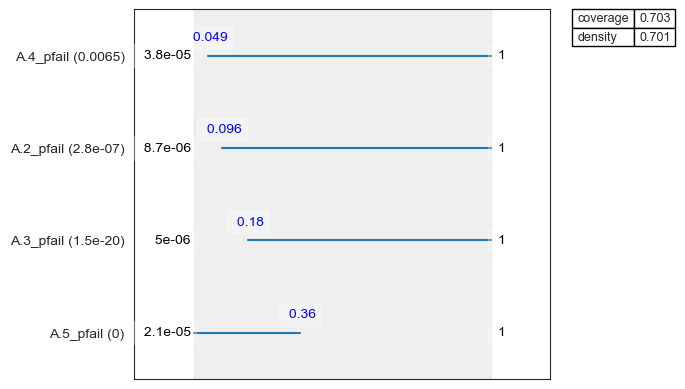

In [14]:
box.inspect(point, style='graph')
plt.show()

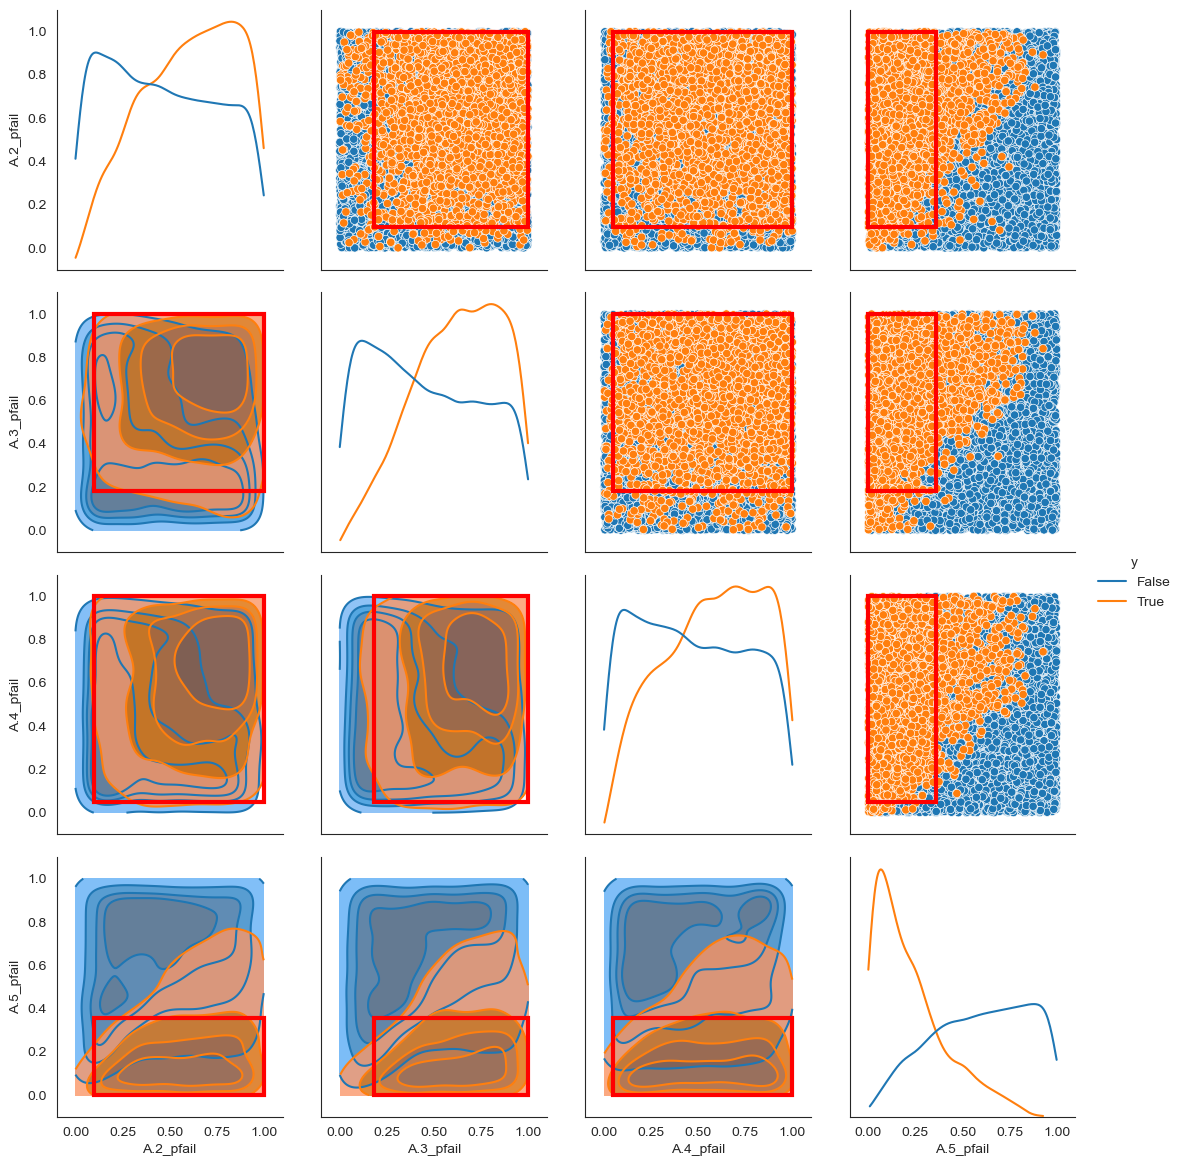

In [15]:
box.select(point)
box.show_pairs_scatter()
fig = plt.gcf()
fig.set_size_inches(12,12)
plt.show()

In [6]:
y_array = y_prim.values

NameError: name 'y_prim' is not defined

C:\Users\milan\AppData\Local\Temp\ipykernel_26808\1255276283.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 800x600 with 0 Axes>

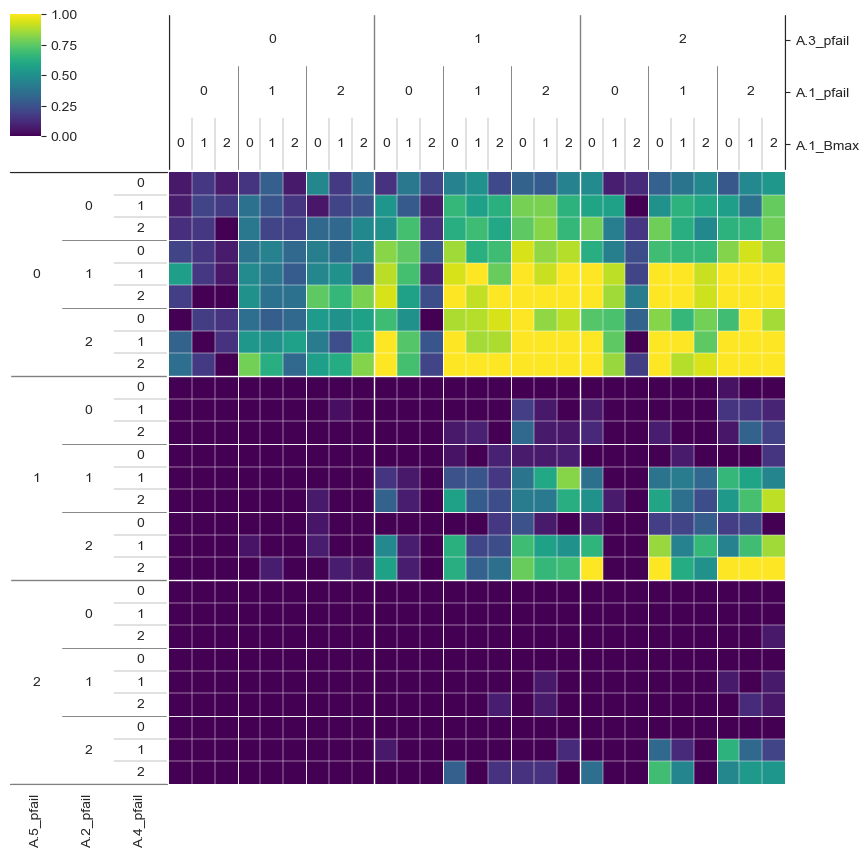

In [17]:
#Hier kan Dimensional Stacking
plt.figure(figsize=(8, 6))
dimensional_stacking.create_pivot_plot(experiments_of_interest, y_array)
plt.tight_layout()
plt.show()

In [7]:
from ema_workbench import Scenario

scenarios = [
    Scenario(f"Scenario {i}", **row.to_dict())
    for i, row in selected_experiments.iterrows()
]

In [8]:
import multiprocessing
print("Number of CPU cores:", multiprocessing.cpu_count())

Number of CPU cores: 12


In [13]:
#test voor sneller werkend
from ema_workbench import ema_logging, Scenario
from ema_workbench.em_framework.optimization import (
    ArchiveLogger, EpsilonProgress, to_problem,
    epsilon_nondominated, HypervolumeMetric
)
from ema_workbench import MultiprocessingEvaluator
import pandas as pd
import numpy as np
import os


def clean_name(name, prefix="L_"):
    clean = name.replace(" ", "_").replace(".", "_").replace("-", "_")
    if clean[0].isdigit():
        clean = prefix + clean
    return clean

def clean_column_names(df, prefix="L_"):
    df = df.copy()
    df.columns = [clean_name(col, prefix=prefix) for col in df.columns]
    return df

def safe_epsilon_nondominated(df, epsilons, problem):
    eps = []
    for col, eps_val in zip(df.columns, epsilons):
        if df[col].nunique() <= 1:
            eps.append(np.inf)
        else:
            eps.append(eps_val)

    nd_array = epsilon_nondominated([df], eps, problem)  # Let op: lijst met 1 dataframe
    nd_df = pd.DataFrame(nd_array, columns=df.columns)

    # Eventueel: voeg originele index toe als dat belangrijk is
    return nd_df

objectives_of_interest = [
    "RfR Total Costs",
    "Expected Evacuation Costs",
    "A.5 Total Costs",
    "A.5_Expected Number of Deaths"
]

cleaned_objectives_of_interest = [clean_name(o, "O_") for o in objectives_of_interest]

if __name__ == "__main__":
    ema_logging.log_to_stderr(ema_logging.INFO)

    for scenario in scenarios:
        for run_id in range(5):
            print(f"\n🔁 Running optimization for scenario: {scenario.name}, run: {run_id}")

            model, steps = get_model_for_problem_formulation(3)

            reference_values = {"Bmax": 175, "Brate": 1.5, "pfail": 0.5,
                                "discount rate 0": 3.5, "discount rate 1": 3.5,
                                "discount rate 2": 3.5, "ID flood wave shape": 4}

            scen1 = {}
            for key in model.uncertainties:
                name_split = key.name.split("_")
                key_id = name_split[1] if len(name_split) > 1 else key.name
                scen1[key.name] = reference_values[key_id]

            ref_scenario = Scenario("reference", **scen1)

            cleaned_lever_names = [l.name for l in model.levers]
            cleaned_outcome_names = [o.name for o in model.outcomes]

            archive_path = f"./archives/optimization_{scenario.name}_run{run_id}.tar.gz"
            os.makedirs("./archives", exist_ok=True)
            if os.path.exists(archive_path):
                os.remove(archive_path)

            convergence_metrics = [
                ArchiveLogger("./archives", cleaned_lever_names, cleaned_outcome_names,
                              base_filename=f"optimization_{scenario.name}_run{run_id}.tar.gz"),
                EpsilonProgress()
            ]

            with MultiprocessingEvaluator(model) as evaluator:
                results, convergence = evaluator.optimize(
                    nfe=100,
                    searchover='levers',
                    convergence=convergence_metrics,
                    epsilons=[0.05] * len(model.outcomes),
                    reference=ref_scenario
                )

            for lever in model.levers:
                lever.name = clean_name(lever.name, "L_")

            names_to_keep = []
            for o in model.outcomes:
                cleaned = clean_name(o.name, prefix="O_")
                if cleaned in cleaned_objectives_of_interest:
                    names_to_keep.append(o.name)

            for name in list(model.outcomes.keys()):
                if name not in names_to_keep:
                    del model.outcomes[name]

            for o in model.outcomes:
                o.name = clean_name(o.name, prefix="O_")

            print(f"✅ Filtered outcomes for scenario {scenario.name} (run {run_id}):")
            for o in model.outcomes:
                print(o.name)

            problem = to_problem(model, searchover="levers")
            problem._outcome_names = cleaned_objectives_of_interest

            archive_test = ArchiveLogger.load_archives(archive_path)
            archive_test_clean = {k: clean_column_names(v) for k, v in archive_test.items()}
            final_gen = archive_test_clean[max(archive_test_clean)]
            print(final_gen)

            relevant = final_gen[cleaned_objectives_of_interest]
            nondominated_objectives = safe_epsilon_nondominated(relevant, [0.05] * len(cleaned_objectives_of_interest), problem)
            mask = relevant.apply(tuple, axis=1).isin(nondominated_objectives.apply(tuple, axis=1))
            reference_set = final_gen.loc[mask].reset_index(drop=True)
            print(reference_set)

            hv_metric = HypervolumeMetric(reference_set, problem)
            metrics = []
            for nfe, archive in archive_test_clean.items():
                scores = {"hypervolume": hv_metric.calculate(archive), "nfe": nfe}
                metrics.append(scores)

            metrics_df = pd.DataFrame(metrics).sort_values(by="nfe").reset_index(drop=True)
            metrics_df["epsilon_progress"] = convergence["epsilon_progress"]
            metrics_df["seed"] = run_id
            metrics_df["scenario"] = scenario.name

            os.makedirs("./convergence_metrics", exist_ok=True)
            metrics_df.to_csv(f"./convergence_metrics/metrics_{scenario.name}_run{run_id}.csv", index=False)
            print(f"💾 Saved convergence metrics for scenario {scenario.name}, run {run_id}")


🔁 Running optimization for scenario: Scenario 0, run: 0


[MainProcess/INFO] pool started with 12 workers
100%|████████████████████████████████████████| 100/100 [00:07<00:00, 12.75it/s]
[MainProcess/INFO] optimization completed, found 70 solutions
[MainProcess/INFO] terminating pool


✅ Filtered outcomes for scenario Scenario 0 (run 0):
A_5_Total_Costs
A_5_Expected_Number_of_Deaths
RfR_Total_Costs
Expected_Evacuation_Costs


EMAError: The number of columns in the archive (4) does not match the expected number of decision variables and objectives (35).

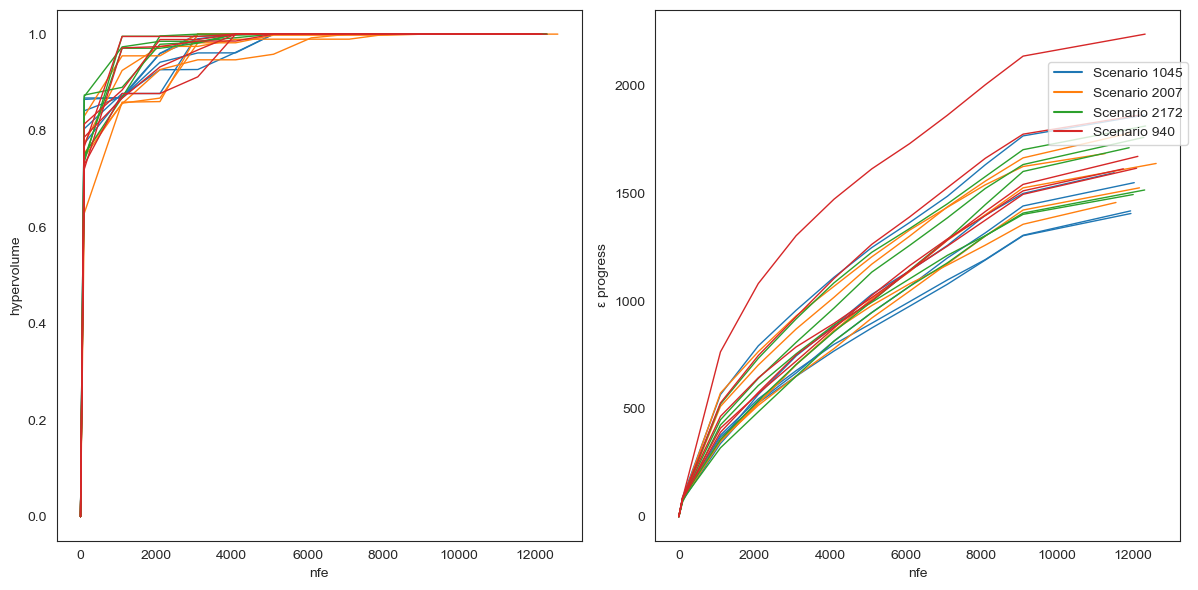

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load all saved metrics
all_metrics = []
metrics_dir = "./convergence_metrics"

for file in os.listdir(metrics_dir):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(metrics_dir, file))
        all_metrics.append(df)

convergence = pd.concat(all_metrics, ignore_index=True)

# Plotting
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
colors = sns.color_palette()
legend_items = []

for (scenario_name, scores), color in zip(convergence.groupby("scenario"), colors):
    legend_items.append((plt.Line2D([0, 1], [0, 1], color=color), scenario_name))
    for seed, score in scores.groupby("seed"):
        ax1.plot(score.nfe, score.hypervolume, c=color, lw=1)
        ax2.plot(score.nfe, score.epsilon_progress, c=color, lw=1)

ax1.set_ylabel('hypervolume')
ax1.set_xlabel('nfe')
ax2.set_ylabel('ε progress')
ax2.set_xlabel('nfe')
artists, labels = zip(*legend_items)
fig.legend(artists, labels, bbox_to_anchor=(1, 0.9))
plt.tight_layout()
plt.show()

In [27]:
#Werkt, maar is langzaam

from ema_workbench import ema_logging, Scenario
from problem_formulation import get_model_for_problem_formulation  # ensure this is correct
from ema_workbench.em_framework.optimization import ArchiveLogger, EpsilonProgress, to_problem, epsilon_nondominated, HypervolumeMetric
from ema_workbench import MultiprocessingEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import os


def clean_name(name, prefix="L_"):
    clean = name.replace(" ", "_").replace(".", "_").replace("-", "_")
    if clean[0].isdigit():
        clean = prefix + clean
    return clean

def clean_column_names(df, prefix="L_"):
    df = df.copy()
    df.columns = [clean_name(col, prefix=prefix) for col in df.columns]
    return df

objectives_of_interest = [
    "A.5 Total Costs",
    "A.5_Expected Number of Deaths"
]

cleaned_objectives_of_interest = [clean_name(o, "O_") for o in objectives_of_interest]

if __name__ == "__main__":
    ema_logging.log_to_stderr(ema_logging.INFO)

    for scenario in scenarios:
        for run_id in range(5):
            print(f"\n🔁 Running optimization for scenario: {scenario.name}, run: {run_id}")

            model, steps = get_model_for_problem_formulation(3)

            reference_values = {
                "Bmax": 175,
                "Brate": 1.5,
                "pfail": 0.5,
                "discount rate 0": 3.5,
                "discount rate 1": 3.5,
                "discount rate 2": 3.5,
                "ID flood wave shape": 4,
            }

            scen1 = {}
            for key in model.uncertainties:
                name_split = key.name.split("_")
                key_id = name_split[1] if len(name_split) > 1 else key.name
                scen1[key.name] = reference_values[key_id]

            ref_scenario = Scenario("reference", **scen1)

            cleaned_lever_names = [clean_name(l.name, "L_") for l in model.levers]
            cleaned_outcome_names = [clean_name(o.name, "O_") for o in model.outcomes]

            archive_path = f"./archives/optimization_{scenario.name}_run{run_id}.tar.gz"
            os.makedirs("./archives", exist_ok=True)
            if os.path.exists(archive_path):
                os.remove(archive_path)

            convergence_metrics = [
                ArchiveLogger(
                    "./archives",
                    cleaned_lever_names,
                    cleaned_outcome_names,
                    base_filename=f"optimization_{scenario.name}_run{run_id}.tar.gz",
                ),
                EpsilonProgress(),
            ]

            with MultiprocessingEvaluator(model) as evaluator:
                results, convergence = evaluator.optimize(
                    nfe=10000,
                    searchover='levers',
                    convergence=convergence_metrics,
                    epsilons=[0.05] * len(model.outcomes),
                    reference=ref_scenario
                )

            archive_test = ArchiveLogger.load_archives(archive_path)
            archive_test_clean = {k: clean_column_names(v) for k, v in archive_test.items()}
            reference_set_clean = clean_column_names(results)

            for lever in model.levers:
                lever.name = clean_name(lever.name, "L_")

            names_to_keep = []
            for o in model.outcomes:
                cleaned = clean_name(o.name, prefix="O_")
                if cleaned in cleaned_objectives_of_interest:
                    names_to_keep.append(o.name)

            for name in list(model.outcomes.keys()):
                if name not in names_to_keep:
                    del model.outcomes[name]

            for o in model.outcomes:
                o.name = clean_name(o.name, prefix="O_")

            print(f"✅ Filtered outcomes for scenario {scenario.name} (run {run_id}):")
            for o in model.outcomes:
                print(o.name)

            problem = to_problem(model, searchover="levers")
            problem._outcome_names = cleaned_objectives_of_interest
            cleaned_lever_names = problem.parameter_names

            reference_set_reduced = reference_set_clean[cleaned_objectives_of_interest + cleaned_lever_names]
            archive_test_reduced = {
                k: v[cleaned_objectives_of_interest + cleaned_lever_names] for k, v in archive_test_clean.items()
            }

            reference_set_final = reference_set_reduced.copy()

            if len(reference_set_final) == 0:
                print(f"⚠️ No non-dominated solutions in run {run_id} of {scenario.name}. Skipping HV calc.")
                continue  # skip the rest of this run

            def calculate_convergence_metrics(problem, archives_file, reference_set):
                hv = HypervolumeMetric(reference_set, problem)
                metrics = []
                for nfe, archive in archives_file.items():
                    scores = {"hypervolume": hv.calculate(archive), "nfe": nfe}
                    metrics.append(scores)
                df = pd.DataFrame.from_dict(metrics)
                df.sort_values(by="nfe", inplace=True, ignore_index=True)
                return df

            metrics = calculate_convergence_metrics(problem, archive_test_reduced, reference_set_final)
            if metrics.empty:
                print(f"⚠️ No valid metrics in run {run_id} of {scenario.name}.")
                continue
            print(metrics)

            epsilon_nfe = convergence["nfe"]
            epsilon_values = convergence["epsilon_progress"]
            hv_nfe = metrics["nfe"]
            hv_values = metrics["hypervolume"]

            metrics["seed"] = run_id
            metrics["scenario"] = scenario.name
            metrics["epsilon_progress"] = [v for v in epsilon_values]  # assuming alignment by index

            # Save metrics to disk
            save_dir = "./convergence_metrics"
            os.makedirs(save_dir, exist_ok=True)
            metrics_file = os.path.join(save_dir, f"metrics_{scenario.name}_run{run_id}.csv")
            metrics.to_csv(metrics_file, index=False)
            print(f"💾 Saved convergence metrics to {metrics_file}")


🔁 Running optimization for scenario: Scenario 940, run: 0


KeyboardInterrupt: 